In [1]:
import pandas

In [2]:
import matplotlib, matplotlib.pyplot
matplotlib.rcParams.update({'font.size':20, 
                            'font.family':'sans-serif', 
                            'xtick.labelsize':16, 
                            'ytick.labelsize':16, 
                            'figure.figsize':(16*(2/3), 9*(2/3)), 
                            'axes.labelsize':20
                           })

In [3]:
input_file = '/Users/adrian/research/bmcbf/004_keilir/results/post_idr_peaks/tmp.m.step3.bed'

In [4]:
df = pandas.read_csv(input_file, sep='\t', header=None)
df

,0,1,2,3,4,5,6,7,8
0,chr1,910999,911533,7.30273,18.26490,5.42102,14.70320,7.36534,18.4476
1,chr1,938208,939202,7.86549,18.54170,4.61527,8.45915,3.9631,5.65814
2,chr1,1063677,1064550,4.71931,7.01265,3.74816,6.44583,6.24129,14.2016
3,chr1,1069807,1070955,7.71480,15.94880,5.32207,9.64173,4.80669,8.85323
4,chr1,1072790,1074084,4.60525,7.13673,6.23573,12.97690,4.48319,7.27679
...,...,...,...,...,...,...,...,...,...
19802,chrUn_GL000216v2,141092,142103,10.41570,21.72500,13.37380,31.68520,11.2426,31.6266
19803,chrUn_GL000216v2,154548,155135,11.61480,28.43460,8.89953,30.54320,6.68231,21.5033
19804,chrUn_GL000216v2,163946,164279,8.04099,15.62610,7.88709,13.48410,7.33265,13.9317
19805,chrUn_GL000216v2,173451,174130,9.74373,26.55230,10.86970,38.50450,4.39929,12.2784


In [5]:
bad_mask = pandas.to_numeric(df[3], errors="coerce").isna()
errors = df.loc[bad_mask, 3:6]
print(errors.shape)
errors

(0, 4)


,3,4,5,6


In [6]:
cols = list(range(1, 9))

df[cols] = (
    df[cols]
    .astype(str)
    .apply(lambda col: col.str.strip())
    .replace(".", pandas.NA)
    .apply(lambda col: pandas.to_numeric(col, errors="coerce"))
)
df.dtypes

0     object
1      int64
2      int64
3    float64
4    float64
5    float64
6    float64
7    float64
8    float64
dtype: object

In [7]:
df

,0,1,2,3,4,5,6,7,8
0,chr1,910999,911533,7.30273,18.26490,5.42102,14.70320,7.36534,18.44760
1,chr1,938208,939202,7.86549,18.54170,4.61527,8.45915,3.96310,5.65814
2,chr1,1063677,1064550,4.71931,7.01265,3.74816,6.44583,6.24129,14.20160
3,chr1,1069807,1070955,7.71480,15.94880,5.32207,9.64173,4.80669,8.85323
4,chr1,1072790,1074084,4.60525,7.13673,6.23573,12.97690,4.48319,7.27679
...,...,...,...,...,...,...,...,...,...
19802,chrUn_GL000216v2,141092,142103,10.41570,21.72500,13.37380,31.68520,11.24260,31.62660
19803,chrUn_GL000216v2,154548,155135,11.61480,28.43460,8.89953,30.54320,6.68231,21.50330
19804,chrUn_GL000216v2,163946,164279,8.04099,15.62610,7.88709,13.48410,7.33265,13.93170
19805,chrUn_GL000216v2,173451,174130,9.74373,26.55230,10.86970,38.50450,4.39929,12.27840


In [8]:
df['signal'] = df.iloc[:, [3, 5, 7]].mean(axis=1)
df['Q'] = df.iloc[:, [4, 6, 8]].mean(axis=1)
df

,0,1,2,3,4,5,6,7,8,signal,Q
0,chr1,910999,911533,7.30273,18.26490,5.42102,14.70320,7.36534,18.44760,6.696363,17.138567
1,chr1,938208,939202,7.86549,18.54170,4.61527,8.45915,3.96310,5.65814,5.481287,10.886330
2,chr1,1063677,1064550,4.71931,7.01265,3.74816,6.44583,6.24129,14.20160,4.902920,9.220027
3,chr1,1069807,1070955,7.71480,15.94880,5.32207,9.64173,4.80669,8.85323,5.947853,11.481253
4,chr1,1072790,1074084,4.60525,7.13673,6.23573,12.97690,4.48319,7.27679,5.108057,9.130140
...,...,...,...,...,...,...,...,...,...,...,...
19802,chrUn_GL000216v2,141092,142103,10.41570,21.72500,13.37380,31.68520,11.24260,31.62660,11.677367,28.345600
19803,chrUn_GL000216v2,154548,155135,11.61480,28.43460,8.89953,30.54320,6.68231,21.50330,9.065547,26.827033
19804,chrUn_GL000216v2,163946,164279,8.04099,15.62610,7.88709,13.48410,7.33265,13.93170,7.753577,14.347300
19805,chrUn_GL000216v2,173451,174130,9.74373,26.55230,10.86970,38.50450,4.39929,12.27840,8.337573,25.778400


(5915, 11)
(6641, 11)
(5132, 11)
(2119, 11)


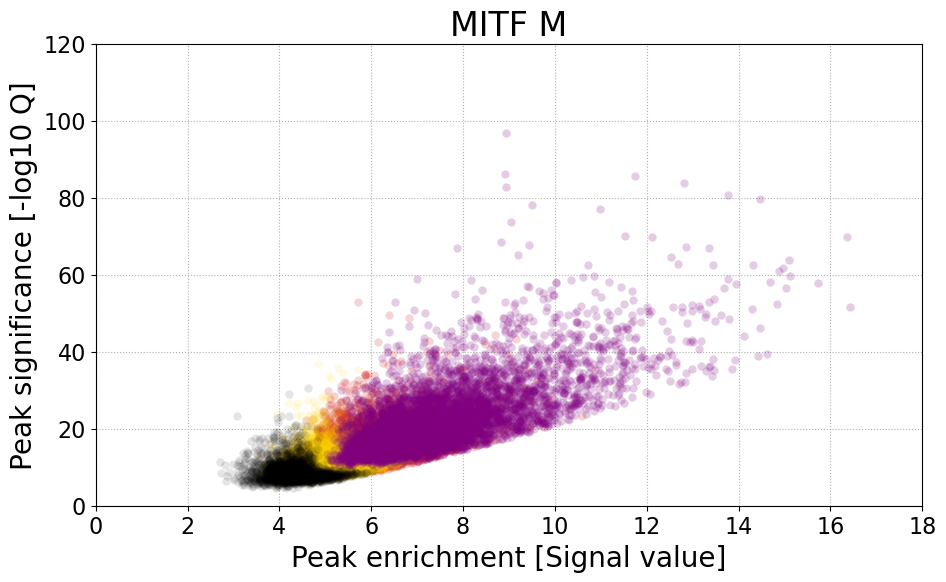

In [9]:
signal_threshold = 5         # encode signal
significance_threshold = 10  # encode significance threshold

# Boolean flags: does replicate i pass both thresholds?
pass_r1 = (df[3] >= signal_threshold) & (df[4] >= significance_threshold)
pass_r2 = (df[5] >= signal_threshold) & (df[6] >= significance_threshold)
pass_r3 = (df[7] >= signal_threshold) & (df[8] >= significance_threshold)

# Count how many replicates pass per row
pass_count = (pandas.concat([pass_r1, pass_r2, pass_r3], axis=1).sum(axis=1))

# arrange
df_black  = df.loc[pass_count == 0].copy()  # none pass
df_yellow = df.loc[pass_count == 1].copy()  # exactly one passes
df_orange = df.loc[pass_count == 2].copy()  # exactly two pass
df_red    = df.loc[pass_count == 3].copy()  # all three pass

print(df_red.shape)
print(df_orange.shape)
print(df_yellow.shape)
print(df_black.shape)

# plot
matplotlib.pyplot.plot(df_orange['signal'], df_orange['Q'], 'o', color='tab:red', alpha=0.2, mec='none')
matplotlib.pyplot.plot(df_yellow['signal'], df_yellow['Q'], 'o', color='gold', alpha=0.1, mec='none')
matplotlib.pyplot.plot(df_red['signal'], df_red['Q'], 'o', color='purple', alpha=0.2, mec='none')
matplotlib.pyplot.plot(df_black['signal'], df_black['Q'], 'o', color='black', alpha=0.1, mec='none')

matplotlib.pyplot.xlabel('Peak enrichment [Signal value]')
matplotlib.pyplot.ylabel('Peak significance [-log10 Q]')
matplotlib.pyplot.grid(ls=':')


matplotlib.pyplot.xlim(0, 18)
matplotlib.pyplot.ylim(0, 120)

matplotlib.pyplot.title('MITF M')

matplotlib.pyplot.show()

In [10]:
df_red.to_csv('/Users/adrian/research/bmcbf/004_keilir/results/differential_peaks/purple.m.bed', header=False, index=False, sep='\t')